In [14]:
import numpy as np

In [15]:
class MultinomialRegression:
      def __init__(self, lr=0.1, iterations=500):
        self.lr = lr
        self.iterations = iterations
        self.W = None
        self.b = None

      def softmax(self,z):
        z = z - np.max(z, axis=1, keepdims=True) # improve numerical stability and prevent overflow in exp()
        exp_z= np.exp(z)
        return  exp_z/np.sum(exp_z, axis=1, keepdims=True)
      
      def one_hot(self, y, num_classes):
        
        y = np.array(y, dtype=int)
        identity = np.eye(num_classes)
    
        # Use y to PICK rows from the identity matrix
        one_hot = identity[y]
        return one_hot
        
      def compute_loss(Self,y_true,y_hat):
         epsilon = 1e-15  # small value to avoid log(0)
         y_hat = np.clip(y_hat, epsilon, 1 - epsilon)

        # Since y_true is one-hot, this picks only the correct class probability
         loss_per_sample = np.sum(y_true * np.log(y_hat), axis=1)
         loss = - np.mean(loss_per_sample)

         return loss
      
      def compute_gradients(self, X, y_true, y_hat):
  
        n_samples = X.shape[0]
        dz = y_hat - y_true  

        
        dW = (X.T @ dz) / n_samples  
        db = np.sum(dz, axis=0) / n_samples   

        return dW, db
      
      def fit(self, X, y):
   
        # Get dimensions from data
        n_samples, n_features = X.shape
        n_classes = 10

        # Initialize weights and bias (now we know shapes)
        self.W = np.zeros((n_features, n_classes))
        self.b = np.zeros(n_classes)

        # Convert labels to one-hot encoding
        y_one_hot = self.one_hot(y, n_classes)

        # Training loop
        for i in range(self.iterations):

            z = X @ self.W + self.b             
            y_hat = self.softmax(z)             

            #  Compute loss 
            if i % 100 == 0:
                loss = self.compute_loss(y_one_hot, y_hat)
                print(f"Iteration {i}, Loss: {loss:.4f}")

            #  Compute gradients
            dW, db = self.compute_gradients(X, y_one_hot, y_hat)

            #  Update parameters
            self.W -= self.lr * dW
            self.b -= self.lr * db

      def predict(self, X):
        if self.W is None:
            raise ValueError("Model is not trained yet. Call fit() first.")

        # Compute scores
        z = X @ self.W + self.b

        y_hat = self.softmax(z)

        # Pick class with highest probability
        y_pred = np.argmax(y_hat, axis=1)

        return y_pred





In [16]:
from preprocessing2 import preprocess
X_train, y_train, X_val, y_val, X_test, y_test, _ = preprocess( feature_method="hog" , n_pca=100)

model = MultinomialRegression(lr=0.5, iterations=1000)
model.fit(X_train, y_train)

Loading MNIST dataset...
Split completed: Train=54000, Val=6000, Test=10000
Iteration 0, Loss: 2.3026
Iteration 100, Loss: 0.6038
Iteration 200, Loss: 0.4391
Iteration 300, Loss: 0.3729
Iteration 400, Loss: 0.3350
Iteration 500, Loss: 0.3096
Iteration 600, Loss: 0.2911
Iteration 700, Loss: 0.2768
Iteration 800, Loss: 0.2652
Iteration 900, Loss: 0.2556


In [17]:
def evaluate_model(X, y, model, dataset_name="Validation"):
    """
    Evaluate multiclass model (digits 0-9)
    """

    y_pred = model.predict(X)
    y_true = y

    n_classes = 10  # MNIST

    #  Confusion Matrix
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[int(t), int(p)] += 1

    #  Accuracy
    accuracy = np.trace(cm) / np.sum(cm)

    #  Precision, Recall, F1 per class
    precision = np.zeros(n_classes)
    recall = np.zeros(n_classes)
    f1 = np.zeros(n_classes)

    for i in range(n_classes):
        tp = cm[i, i]
        fp = np.sum(cm[:, i]) - tp
        fn = np.sum(cm[i, :]) - tp

        precision[i] = tp / (tp + fp + 1e-9)
        recall[i]    = tp / (tp + fn + 1e-9)
        f1[i]        = 2 * precision[i] * recall[i] / (precision[i] + recall[i] + 1e-9)

    #  Macro F1
    macro_f1 = np.mean(f1)

    #  Print results
    print(f"\n--- {dataset_name} Results ---")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Macro F1  : {macro_f1:.4f}")

    # Confusion Matrix
    print("\nConfusion Matrix:")
    print(cm)

    # Classification Report
    print("\nClassification Report:")
    print(f"{'Class':<10}{'Precision':>10}{'Recall':>10}{'F1-score':>12}")

    for i in range(n_classes):
        print(f"{i:<10}{precision[i]:>10.2f}{recall[i]:>10.2f}{f1[i]:>12.2f}")

In [18]:
evaluate_model(X_val, y_val, model, "Validation")


--- Validation Results ---
Accuracy  : 0.9513
Macro F1  : 0.9512

Confusion Matrix:
[[564   6   9   1   0   3   1   0   1   2]
 [  0 615   4   1   3   0   1   1   5   0]
 [  3   0 576   4   5   1   2   5   4   0]
 [  0   0  14 599   1   6   0   1   3   3]
 [  0   5   0   0 568   0   2   5   1  14]
 [  1   2   1  17   0 508   2   1  12   5]
 [  1   0   1   0   4   2 562   0   0   1]
 [  1   0   6   1   5   0   1 629   1  24]
 [  6   4   7   5   2   3   4   2 559   5]
 [  6   3   0   8   9   3   0  15   4 528]]

Classification Report:
Class      Precision    Recall    F1-score
0               0.97      0.96        0.96
1               0.97      0.98        0.97
2               0.93      0.96        0.95
3               0.94      0.96        0.95
4               0.95      0.95        0.95
5               0.97      0.93        0.95
6               0.98      0.98        0.98
7               0.95      0.94        0.95
8               0.95      0.94        0.94
9               0.91      0.92

In [19]:

evaluate_model(X_test, y_test, model, "Test")


--- Test Results ---
Accuracy  : 0.9405
Macro F1  : 0.9403

Confusion Matrix:
[[ 953    3    7    0    3    4    2    0    2    6]
 [   2 1118    5    4    3    1    1    0    1    0]
 [   8    2  957   13    7    2    4   16   20    3]
 [   3    0   17  952    2   16    0   12    5    3]
 [   0   10    1    0  922    0    4    7    7   31]
 [   4    1    0   20    0  837    5    1   18    6]
 [   7    6    1    0   10    7  921    0    6    0]
 [   0    8   40    1   12    0    0  917    9   41]
 [  10    4   12    5    4    6    5    6  912   10]
 [   4    4    3   11   32    8    1   25    5  916]]

Classification Report:
Class      Precision    Recall    F1-score
0               0.96      0.97        0.97
1               0.97      0.99        0.98
2               0.92      0.93        0.92
3               0.95      0.94        0.94
4               0.93      0.94        0.93
5               0.95      0.94        0.94
6               0.98      0.96        0.97
7               0.93  

Loading MNIST dataset...
Split completed: Train=54000, Val=6000, Test=10000
GENERATING LEARNING CURVES

Training on 5400 samples (10%)
Iteration 0, Loss: 2.3026
Iteration 100, Loss: 0.5919
Iteration 200, Loss: 0.4249
Iteration 300, Loss: 0.3570
Iteration 400, Loss: 0.3179
Iteration 500, Loss: 0.2914
Iteration 600, Loss: 0.2720
Iteration 700, Loss: 0.2568
Iteration 800, Loss: 0.2445
Iteration 900, Loss: 0.2342
Train Accuracy     : 0.9428
Validation Accuracy: 0.9455

Training on 10800 samples (20%)
Iteration 0, Loss: 2.3026
Iteration 100, Loss: 0.5998
Iteration 200, Loss: 0.4340
Iteration 300, Loss: 0.3671
Iteration 400, Loss: 0.3287
Iteration 500, Loss: 0.3028
Iteration 600, Loss: 0.2839
Iteration 700, Loss: 0.2691
Iteration 800, Loss: 0.2571
Iteration 900, Loss: 0.2471
Train Accuracy     : 0.9367
Validation Accuracy: 0.9520

Training on 16200 samples (30%)
Iteration 0, Loss: 2.3026
Iteration 100, Loss: 0.6079
Iteration 200, Loss: 0.4435
Iteration 300, Loss: 0.3772
Iteration 400, Loss: 

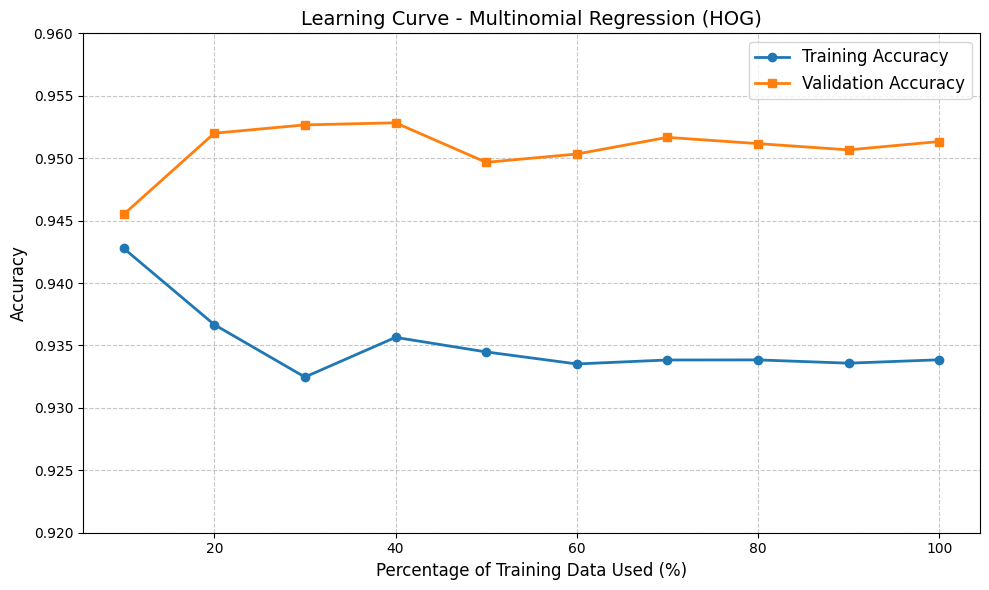


MODEL DIAGNOSIS
Final Training Accuracy  : 0.9339
Final Validation Accuracy: 0.9513
Gap                      : -0.0175

Diagnosis: GOOD GENERALIZATION
The model generalizes well.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from preprocessing2 import (
    preprocess,
    custom_accuracy_score
)

# =====================================================
# CHANGE THESE SETTINGS TO TEST DIFFERENT CONFIGURATIONS
# =====================================================

FEATURE_METHOD = "hog"     # "flatten" | "pca" | "hog"
N_PCA = 100                # used only if feature_method="pca"

LEARNING_RATE = 0.5
ITERATIONS = 1000

# =====================================================
# LOAD DATA
# =====================================================

if FEATURE_METHOD == "pca":

    X_train, y_train, X_val, y_val, X_test, y_test, _ = preprocess(
        feature_method="pca",
        n_pca=N_PCA
    )

else:

    X_train, y_train, X_val, y_val, X_test, y_test, _ = preprocess(
        feature_method=FEATURE_METHOD
    )

# =====================================================
# LEARNING CURVE SETTINGS
# =====================================================

train_fractions = np.linspace(0.1, 1.0, 10)

train_scores = []
val_scores = []

total_train_samples = len(X_train)

print("=" * 60)
print("GENERATING LEARNING CURVES")
print("=" * 60)

# =====================================================
# TRAIN ON DIFFERENT DATASET SIZES
# =====================================================

for fraction in train_fractions:

    subset_size = int(total_train_samples * fraction)

    print(
        f"\nTraining on {subset_size} samples "
        f"({int(fraction * 100)}%)"
    )

    # -------------------------------------------------
    # RANDOM SUBSET SELECTION
    # -------------------------------------------------

    indices = np.random.choice(
        total_train_samples,
        subset_size,
        replace=False
    )

    X_subset = X_train[indices]
    y_subset = y_train[indices]

    # -------------------------------------------------
    # CREATE MODEL
    # -------------------------------------------------

    curve_model = MultinomialRegression(
        lr=LEARNING_RATE,
        iterations=ITERATIONS
    )

    # -------------------------------------------------
    # TRAIN MODEL
    # -------------------------------------------------

    curve_model.fit(X_subset, y_subset)

    # -------------------------------------------------
    # PREDICTIONS
    # -------------------------------------------------

    train_preds = curve_model.predict(X_subset)
    val_preds = curve_model.predict(X_val)

    # -------------------------------------------------
    # ACCURACY
    # -------------------------------------------------

    train_acc = custom_accuracy_score(
        y_subset,
        train_preds
    )

    val_acc = custom_accuracy_score(
        y_val,
        val_preds
    )

    train_scores.append(train_acc)
    val_scores.append(val_acc)

    print(f"Train Accuracy     : {train_acc:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")

# =====================================================
# PLOT LEARNING CURVES
# =====================================================

plt.figure(figsize=(10, 6))

plt.plot(
    train_fractions * 100,
    train_scores,
    marker="o",
    linewidth=2,
    label="Training Accuracy"
)

plt.plot(
    train_fractions * 100,
    val_scores,
    marker="s",
    linewidth=2,
    label="Validation Accuracy"
)

plt.title(
    f"Learning Curve - Multinomial Regression ({FEATURE_METHOD.upper()})",
    fontsize=14
)

plt.xlabel(
    "Percentage of Training Data Used (%)",
    fontsize=12
)

plt.ylabel(
    "Accuracy",
    fontsize=12
)

plt.legend(fontsize=12)

plt.grid(
    True,
    linestyle="--",
    alpha=0.7
)

plt.ylim(0.92, 0.96)

plt.tight_layout()
plt.show()

# =====================================================
# FINAL DIAGNOSIS
# =====================================================

final_train = train_scores[-1]
final_val = val_scores[-1]

gap = np.abs(final_train - final_val)

print("\n" + "=" * 60)
print("MODEL DIAGNOSIS")
print("=" * 60)

print(f"Final Training Accuracy  : {final_train:.4f}")
print(f"Final Validation Accuracy: {final_val:.4f}")
print(f"Gap                      : {gap:.4f}")

if final_train < 0.85 and final_val < 0.85:

    print("\nDiagnosis: UNDERFITTING")
    print("Suggestions:")
    print("- Increase iterations")
    print("- Use better features (HOG/CNN)")
    print("- Increase PCA dimensions")

elif gap > 0.05:

    print("\nDiagnosis: OVERFITTING")
    print("Suggestions:")
    print("- Add regularization")
    print("- Reduce dimensionality")
    print("- Use more training data")

else:

    print("\nDiagnosis: GOOD GENERALIZATION")
    print("The model generalizes well.")

In [ ]:
import numpy as np

from preprocessing2 import (
    preprocess,
    custom_macro_f1_score,
    k_fold_indices
)


# Feature extraction methods to test
feature_methods = [
    "pca",
    "hog"
]


# Hyperparameter grid
param_grid = {
    "lr": [0.01, 0.08, 0.5],
    "iterations": [300, 600, 1000]
}

# PCA dimensions to test
pca_components_list = [100]


# Tracking best results
best_f1_score = 0
best_params = {}


# Start experiments
experiment_num = 1

for feature_method in feature_methods:

    print("\n" + "=" * 70)
    print(f"TESTING FEATURE METHOD: {feature_method.upper()}")
    print("=" * 70)

    
    # PCA requires trying different n_pca values
    if feature_method == "pca":

        pca_values = pca_components_list

    else:
        # flatten and hog do not need PCA values
        pca_values = [None]

    
    # Loop over PCA dimensions if needed
    for n_pca in pca_values:

       
        if feature_method == "pca":

            print(f"\nUsing PCA with n_components = {n_pca}")

            X_train, y_train, X_val, y_val, X_test, y_test, _ = preprocess(
                feature_method="pca",
                n_pca=n_pca
            )

        else:

            print(f"\nUsing feature method = {feature_method}")

            X_train, y_train, X_val, y_val, X_test, y_test, _ = preprocess(
                feature_method=feature_method
            )

       
        # Create folds
        folds = k_fold_indices(X_train, k=3)

     
        # Hyperparameter Search
        for lr in param_grid["lr"]:

            for iterations in param_grid["iterations"]:

                print(
                    f"\nExperiment {experiment_num}"
                    f" | Method: {feature_method}"
                    f" | PCA: {n_pca}"
                    f" | LR: {lr}"
                    f" | Iterations: {iterations}"
                )

                fold_f1_scores = []

                
                # Cross Validation
                for fold_num, (train_idx, val_idx) in enumerate(folds):

                    # Split fold data
                    X_fold_train = X_train[train_idx]
                    y_fold_train = y_train[train_idx]

                    X_fold_val = X_train[val_idx]
                    y_fold_val = y_train[val_idx]

                    # Create model
                    cv_model = MultinomialRegression(
                        lr=lr,
                        iterations=iterations
                    )

                    # Train model
                    cv_model.fit(X_fold_train, y_fold_train)

                    # Predict
                    preds = cv_model.predict(X_fold_val)

                    # Compute Macro F1
                    fold_f1 = custom_macro_f1_score(
                        y_fold_val,
                        preds,
                        n_classes=10
                    )

                    fold_f1_scores.append(fold_f1)

                    print(
                        f"    Fold {fold_num + 1} "
                        f"Macro F1: {fold_f1:.4f}"
                    )

               
                # Average F1 across folds
                avg_f1 = np.mean(fold_f1_scores)

                print(
                    f"--> Average 3-Fold Macro F1: "
                    f"{avg_f1:.4f}"
                )

                
                # Save best configuration
                if avg_f1 > best_f1_score:

                    best_f1_score = avg_f1

                    best_params = {
                        "feature_method": feature_method,
                        "n_pca": n_pca,
                        "lr": lr,
                        "iterations": iterations
                    }

                experiment_num += 1


# Final Results
print("\n" + "=" * 70)
print("GRID SEARCH COMPLETE")
print("=" * 70)

print(f"\nBest Macro F1 Score: {best_f1_score:.4f}")

print("\nBest Configuration:")
for key, value in best_params.items():
    print(f"{key}: {value}")


TESTING FEATURE METHOD: PCA

Using PCA with n_components = 100
Loading MNIST dataset...
Split completed: Train=54000, Val=6000, Test=10000

Experiment 1 | Method: pca | PCA: 100 | LR: 0.01 | Iterations: 300
Iteration 0, Loss: 2.3026
Iteration 100, Loss: 1.5294
Iteration 200, Loss: 1.1792
    Fold 1 Macro F1: 0.7858
Iteration 0, Loss: 2.3026
Iteration 100, Loss: 1.5313
Iteration 200, Loss: 1.1820
    Fold 2 Macro F1: 0.7875
Iteration 0, Loss: 2.3026
Iteration 100, Loss: 1.5371
Iteration 200, Loss: 1.1874
    Fold 3 Macro F1: 0.7963
--> Average 3-Fold Macro F1: 0.7899

Experiment 2 | Method: pca | PCA: 100 | LR: 0.01 | Iterations: 600
Iteration 0, Loss: 2.3026
Iteration 100, Loss: 1.5294
Iteration 200, Loss: 1.1792
Iteration 300, Loss: 0.9940
Iteration 400, Loss: 0.8797
Iteration 500, Loss: 0.8017
    Fold 1 Macro F1: 0.8254
Iteration 0, Loss: 2.3026
Iteration 100, Loss: 1.5313
Iteration 200, Loss: 1.1820
Iteration 300, Loss: 0.9970
Iteration 400, Loss: 0.8828
Iteration 500, Loss: 0.804

In [25]:
from preprocessing2 import preprocess
X_train, y_train, X_val, y_val, X_test, y_test, _ = preprocess( feature_method="hog" , n_pca=100)
model1 = MultinomialRegression(lr=0.5, iterations=1000)
model1.fit(X_train, y_train)

Loading MNIST dataset...
Split completed: Train=54000, Val=6000, Test=10000
Iteration 0, Loss: 2.3026
Iteration 100, Loss: 0.6038
Iteration 200, Loss: 0.4391
Iteration 300, Loss: 0.3729
Iteration 400, Loss: 0.3350
Iteration 500, Loss: 0.3096
Iteration 600, Loss: 0.2911
Iteration 700, Loss: 0.2768
Iteration 800, Loss: 0.2652
Iteration 900, Loss: 0.2556


In [26]:
evaluate_model(X_test, y_test, model1, "Test")


--- Test Results ---
Accuracy  : 0.9405
Macro F1  : 0.9403

Confusion Matrix:
[[ 953    3    7    0    3    4    2    0    2    6]
 [   2 1118    5    4    3    1    1    0    1    0]
 [   8    2  957   13    7    2    4   16   20    3]
 [   3    0   17  952    2   16    0   12    5    3]
 [   0   10    1    0  922    0    4    7    7   31]
 [   4    1    0   20    0  837    5    1   18    6]
 [   7    6    1    0   10    7  921    0    6    0]
 [   0    8   40    1   12    0    0  917    9   41]
 [  10    4   12    5    4    6    5    6  912   10]
 [   4    4    3   11   32    8    1   25    5  916]]

Classification Report:
Class      Precision    Recall    F1-score
0               0.96      0.97        0.97
1               0.97      0.99        0.98
2               0.92      0.93        0.92
3               0.95      0.94        0.94
4               0.93      0.94        0.93
5               0.95      0.94        0.94
6               0.98      0.96        0.97
7               0.93  